# GRPO

[GRPO](https://hugging-face.cn/learn/llm-course/chapter12/3b)

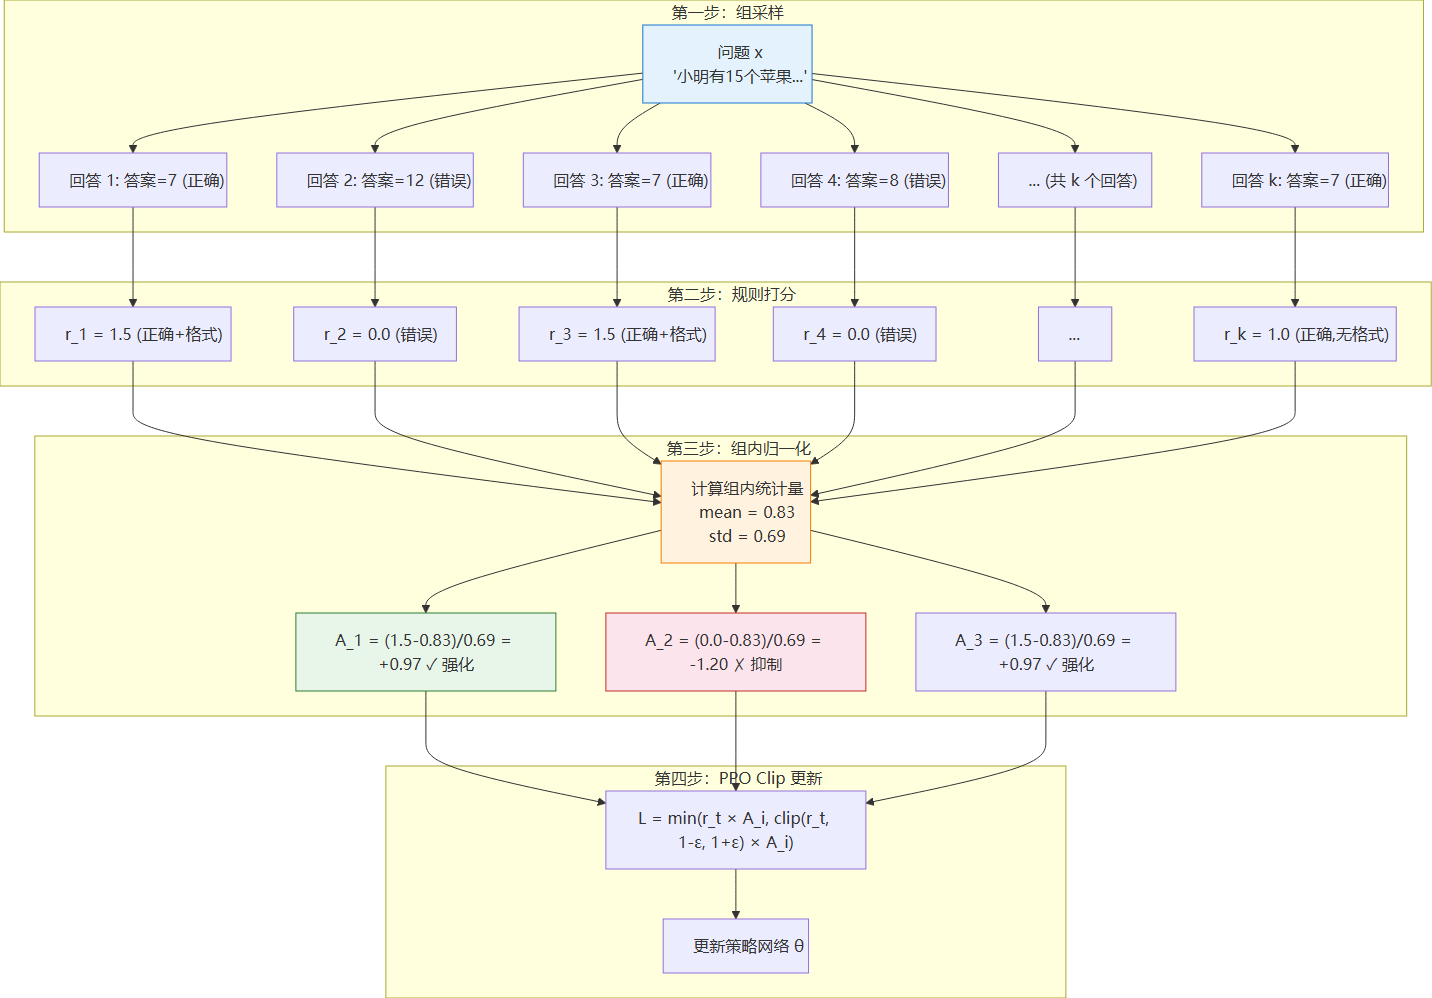

PPO需要critic模型来评估baseline，然后用GAE计算advantage

而GRPO不需要critic模型，他用一个prompt下的多个response的组内reward统计来作为baseline

有了baseline， 可计算advantage = reward - baseline，这样模型能够学到比预期（baseline）更好的动作 

会发现DPO是不需要baseline的，因为他从两个答案中选答案， 本身就是一个相对数据

token_rewards
      ↓
compute_group_advantages()
      ↓
advantages
      ↓
new_log_probs、old_log_probs
      ↓
PPO policy_loss()
      ↓
pg_loss
      ↓
加上 reference KL
      ↓
GRPO total loss
      ↓
backward()

## 加载模型并生成回复

下面代码中num_generations = 4 代表 ， GRPO对于一个问题会生成4个回答， 然后对着四个回答进行排序评分，然后对每个回答算出一个advantage 

部分注释 
1. logits = logits/temperature 后再进行随机挑选， temperature < 1 的时候， 就是相当于放大整个logits，但是对于高概率的logits的提升相较于低logits的幅度更加大 ，所以temperature < 1 其实就是提高概率预测，降低低概率预测。 temperatuer > 1 则相反
2. topk =  10 代表从10个里面随机选取 

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load the model and tokenizer
model_name = "Qwen/Qwen2-Math-1.5B"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.eval()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Input prompt
prompt = "Solve y = 2x + 1 for x = 2, y = "  # Correct answer: 5
inputs = tokenizer(prompt, return_tensors="pt", padding=True)
input_ids = inputs["input_ids"].to(device)  # Shape: (1, prompt_len)
attention_mask = inputs["attention_mask"].to(device)

# Step 1: 生成 8 个响应，因为问题有两个，然后每个对于每个问题生成四个响啊四个响应
batch_size, num_generations = 2, 4
outputs = model.generate(
    input_ids=input_ids,  # Shape: (1, prompt_len)
    attention_mask=attention_mask,
    max_new_tokens=1,  # seq_len = 1 (single token per response)
    num_return_sequences=batch_size * num_generations,  # 8 responses total
    do_sample=True,
    top_k=10,
    temperature=0.7,
    pad_token_id=tokenizer.eos_token_id,
    return_dict_in_generate=True,
    output_scores=True,
)

In [1]:
# 最后输出可能是以下

# Output 1: 5.0
# Output 2: 6.0
# Output 3: 7.0
# Output 4: 5.0
# Output 5: 10.0
# Output 6: 2.0
# Output 7: 5.0
# Output 8: 5.0

## 计算奖励

我们需要确定哪些回复是正确的，并相应地分配奖励。使用 GRPO 时，针对同一个样本提示，我们生成多个补全结果。我们有两组针对给定提示生成的输出，其中一组是[5, 6, 7, 5] 而另一组是
[10, 2, 9, 9]，而正确答案分别是 5 和 9。

在实践中，这些奖励分数通常是通过基于规则的奖励函数（根据回复的正确性分配奖励）或者更复杂的基于神经网络的模型（可以训练该模型来根据正确性或两者结合来分配奖励）来实现的。但为了简单起见，假设如果回复正确，每个回复的奖励为 1，如果错误则为 0，因此；

reward_1 = [1, 0, 0, 1]
reward_2 = [0, 0, 1, 1]

## 计算优势Advantage

GRPO的优势是由于同组的平均和方差计算出来的

advantages = (rewards - mean_grouped_rewards) / (std_grouped_rewards + 1e-8)

In [3]:
import torch
# Shape: (B * G,) = (8,) bc we have 2 groups of 4 generations that we flatten
rewards = torch.tensor([1, 0, 0, 1, 0, 0, 1, 1], dtype=torch.float32)
num_generations = 4

# Group rewards: Shape (B, G) = 2, 4)
rewards_grouped = rewards.view(-1, num_generations)

# Mean per group: Shape (B,) = (2,)
mean_grouped_rewards = rewards_grouped.mean(dim=1)

# Std per group: Shape (B,) = (2,)
std_grouped_rewards = rewards_grouped.std(dim=1)

# Broadcast to match rewards and normalize: Shape (B * G,) = (8,)
# why we need to broadcast? because we need to calculate the advantage values for each response within the group
mean_grouped_rewards = mean_grouped_rewards.repeat_interleave(num_generations, dim=0)
std_grouped_rewards = std_grouped_rewards.repeat_interleave(num_generations, dim=0)

In [5]:
# 输出可能是
# Grouped Rewards: tensor([[1., 0., 0., 1.],
#                         [0., 0., 1., 1.]])
# Mean per group: tensor([0.5000, 0.5000])
# Std per group: tensor([0.5774, 0.5774])
# Broadcasted Mean: tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
# Broadcasted Std: tensor([0.5774, 0.5774, 0.5774, 0.5774, 0.5774, 0.5774, 0.5774, 0.5774])

计算出来结果是：Advantages: tensor([ 0.8659, -0.8660, -0.8660,  0.8659, -0.8660, -0.8660,  0.8659,  0.8659])


## 更新策略

In [ ]:
# Compute probability ratio between new and old policies
ratio = torch.exp(
    new_per_token_logps - per_token_logps
)  

这里他的是max 而不是min，是因为PPO是先max再最后loss函数里面取反，这里先取反再max

然后这里self.beta用于控制KL惩罚的程度， 这里不论是 clipping 和 KL惩罚都是为了防止更新太猛

In [ ]:
# Clipping Function
eps = self.cliprange  # e.g. 0.2
pg_losses1 = -advantages * ratio  # Shape: (B*G, seq_len)  #(8, 1)
pg_losses2 = -advantages * torch.clamp(
    ratio, 1.0 - eps, 1.0 + eps
)  # Shape: (B*G, seq_len) #(8, 1)
pg_loss_max = torch.max(pg_losses1, pg_losses2)  # Shape: (B*G, seq_len) #(8, 1)


# Now Combine with KL penalty # Shape: (B*G, seq_len) #(8, 1)
per_token_loss = pg_loss_max + self.beta * per_token_kl

其中KL散度计算方式如下 

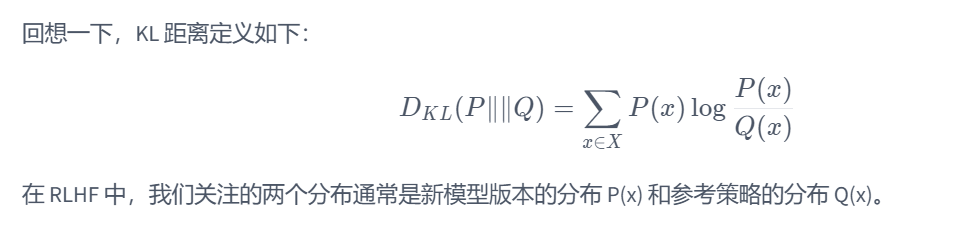



In [7]:
# Shape: (B*G, seq_len) #(8, 1)
per_token_kl = F.kl_div(
    F.log_softmax(new_per_token_logps, dim=-1), # 新策略的log概率
    F.softmax(per_token_logps, dim=-1), # 旧策略下的预测的概率
    reduction="none",
).sum(dim=-1, keepdim=True)

# 值得注意这里为了工程上简洁似乎牺牲logQ的计算

NameError: name 'F' is not defined

### 为什么使用 `k3_kl`？

直接使用单个采样 Token 的对数概率比来估计 KL 散度时，估计值可能为负，并且方差较大。为获得更稳定的逐 Token KL 惩罚，可以使用 `k3` 估计器。

令当前策略为 $\pi_\theta$，参考策略为 $\pi_{\mathrm{ref}}$，并定义：

$$
x = \log \pi_{\mathrm{ref}}(a \mid s) - \log \pi_\theta(a \mid s)
$$

于是概率比为 $r=e^x=\frac{\pi_{\mathrm{ref}}(a \mid s)}{\pi_\theta(a \mid s)}$，`k3` 的逐 Token 估计量为：

$$
\operatorname{k3}(x)=e^x-x-1=r-\log r-1
$$

这正对应下一单元格中的实现：

```python
log_ref_over_policy = ref_log_probs - new_log_probs
per_token_kl = torch.exp(log_ref_over_policy) - log_ref_over_policy - 1.0
```

它有三个实用特点：

1. **始终非负**：当两个策略在该 Token 上的概率相同时，$x=0$，此时 `k3_kl = 0`。
2. **局部平滑**：当两个策略接近、$x\approx0$ 时，$e^x-x-1\approx\frac{x^2}{2}$，惩罚变化较平滑。
3. **计算高效**：只需使用采样 Token 的新策略与参考策略的 log probability，无需显式遍历整个词表。

> 下一单元格先将 `log_ref_over_policy` 截断到 $[-20,20]$，以避免指数运算产生数值溢出。


In [ ]:
    @staticmethod
    def k3_kl(new_log_probs: torch.Tensor, ref_log_probs: torch.Tensor) -> torch.Tensor:
        """VERL low_var_kl / k3 的逐 token 近似。"""
        log_ref_over_policy = torch.clamp(ref_log_probs - new_log_probs, -20.0, 20.0)
        return torch.exp(log_ref_over_policy) - log_ref_over_policy - 1.0


## 总结

GRPO 比较组内的多个输出，以确定哪些比其他的更好，而无需单独的价值模型。（不需要Critic网络）

优势计算标准化了奖励，以识别哪些回复高于或低于平均水平。（不需要GAE）

策略更新使用带有 KL 散度惩罚的裁剪目标函数，以确保学习的稳定性。（相较于ppo的cliping 多了kl）